# Beryllium in water

In [18]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

from ase.io import read

data_path = '../data'
plt.rcParams.update({'font.size': 14})

In [118]:
import numpy as np
import ase.units as units


def get_thermo_props(data_dict, temp=350.0):

    props = {}

    # ---------- density ----------
    def get_density(traj):
        V = np.array([atoms.get_volume() for atoms in traj])  # Å^3
        V_avg = V.mean()

        mass = traj[0].get_masses().sum()  # amu

        rho_amu_A3 = mass / V_avg
        rho_g_cm3 = rho_amu_A3 * 1.66053906660

        return rho_g_cm3

    # ---------- enthalpy ----------
    def get_enthalpy(traj):
        P = 1.01325e5  # Pa
        H = []

        for atoms in traj:
            U = atoms.get_potential_energy() + atoms.get_kinetic_energy()  # eV
            V_m3 = atoms.get_volume() * 1e-30  # Å^3 → m^3
            PV = P * V_m3 / units.eV  # J → eV

            H.append(U + PV)

        return np.array(H)

    # ---------- heat capacity ----------
    def get_heat_capacity(traj):
        H = get_enthalpy(traj)

        kB = units.kB  # eV/K

        Cp_eV_K = np.var(H, ddof=1) / (kB * temp**2)

        # eV/K → kJ/mol/K
        Cp_kJmolK = Cp_eV_K * (units.mol / units.kJ)

        return Cp_kJmolK

    # ---------- compressibility ----------
    def get_compressibility(traj):
        V = np.array([atoms.get_volume() for atoms in traj]) * 1e-30  # m^3
        V_avg = V.mean()

        kB = units.kB / units.eV  # J/K

        kappa_T = np.var(V, ddof=1) / (kB * temp * V_avg**2)

        return kappa_T  # 1/Pa

    # ---------- bulk modulus ----------
    def get_bulk_modulus(traj):
        kappa_T = get_compressibility(traj)
        B = 1.0 / kappa_T  # Pa
        return B / 1e9  # GPa

    # ---------- thermal expansion ----------
    def get_thermal_expansion(traj):
        V = np.array([atoms.get_volume() for atoms in traj]) * 1e-30  # m^3
        H = get_enthalpy(traj)

        dV = V - V.mean()
        dH = H - H.mean()

        kB = units.kB  # eV/K

        cov = np.mean(dV * dH)  # m^3·eV

        alpha = cov / (kB * temp**2 * V.mean())

        return alpha  # 1/K

    # ---------- loop ----------
    for key, traj in data_dict.items():

        H = get_enthalpy(traj)

        props[key] = {
            "density (g/cm^3)": get_density(traj),
            "enthalpy (eV/atomistic system)": H.mean(),
            "heat_capacity (kJ/mol/K)": get_heat_capacity(traj),
            "compressibility (1/Pa)": get_compressibility(traj),
            "bulk_modulus (GPa)": get_bulk_modulus(traj),
            "thermal_expansion (1/K)": get_thermal_expansion(traj),
        }

    return props


def load_data(path_dict, fname):
    """
    Load data files from a set of directories.

    Each entry in ``path_dict`` is searched for a file matching
    ``fname``. Wildcards are allowed, but exactly one file must match
    per directory.
    """
    import glob
    import os

    import pandas as pd
    from ase.io import read

    loaded_data = {}

    for key, path in path_dict.items():

        # Construct full search pattern.
        pattern = os.path.join(data_path + path, fname)

        # Use glob only when the filename contains wildcards.
        if "*" in fname or "?" in fname:
            matches = sorted(glob.glob(pattern))
        else:
            matches = [pattern] if os.path.isfile(pattern) else []

        if len(matches) == 0:
            raise FileNotFoundError(
                f"No files match '{fname}' in '{data_path + path}'."
            )

        if len(matches) > 1:
            raise ValueError(
                f"Multiple files match '{fname}' in '{data_path + path}':\n"
                + "\n".join(matches)
            )

        file_path = matches[0]

        print(f"Loading data for '{key}' from '{file_path}'")

        if file_path.endswith(".csv"):
            loaded_data[key] = pd.read_csv(file_path, sep=";")

        elif file_path.endswith((".pdb", ".xyz", ".traj")):
            loaded_data[key] = read(file_path, ":")

        else:
            raise ValueError(
                f"Unsupported file type: '{file_path}'."
            )

    return loaded_data

In [67]:
MP0_paths = {
    'Be$^{2+}$(aq)':'/MACE-MP-0/112_water/Be2+/',
    'BeCl$_2$(aq)':'/MACE-MP-0/112_water/BeCl2/',
}

MP0_data = load_data(MP0_paths, fname='travis/rdf_Be_O_[Be1r_O1o].csv')

Loading data for 'Be$^{2+}$(aq)' from '../data/MACE-MP-0/112_water/Be2+/travis/rdf_Be_O_[Be1r_O1o].csv'
Loading data for 'BeCl$_2$(aq)' from '../data/MACE-MP-0/112_water/BeCl2/travis/rdf_Be_O_[Be1r_O1o].csv'


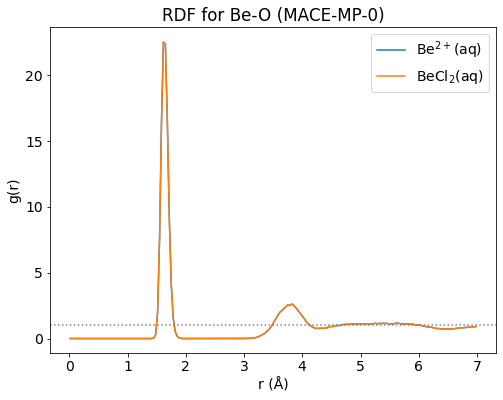

In [68]:
plt.rcParams.update({'font.size': 14})
fig, ax = plt.subplots(figsize=(8, 6))
for key, data in MP0_data.items():
    ax.plot(data['# Distance / pm']/100, data['  g(r)'], label=key)
    rmax = data['# Distance / pm'].max()/100
ax.set_title(f'RDF for Be-O (MACE-MP-0)')
ax.set_xlabel('r (Å)')
ax.set_ylabel('g(r)')
ax.axhline(1, 0, rmax, color='gray', linestyle=':')
ax.legend()
plt.show()

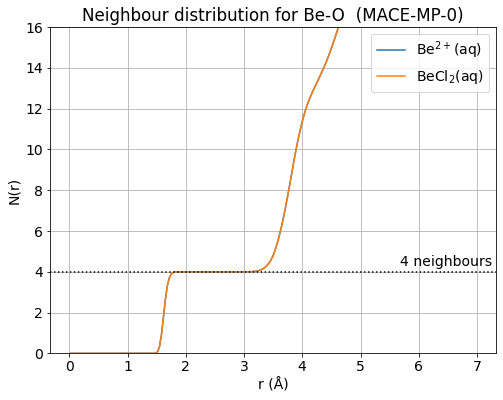

In [72]:
fig, ax = plt.subplots(figsize=(8, 6))
for key, data in MP0_data.items():
    ax.plot(data['# Distance / pm']/100, data['  Integral'], label=key)

y = 4
ax.axhline(4, 0, color='black', linestyle=':')
plt.annotate(
    f"{y} neighbours",
    xy=(1-0.01, y+0.5),
    xycoords=('axes fraction', 'data'),
    ha='right',
    va='center'
)

ax.set_title(f'Neighbour distribution for Be-O  (MACE-MP-0)')
ax.set_xlabel('r (Å)')
ax.set_ylabel('N(r)')
ax.set_ylim(0, 16)
ax.grid()
ax.legend()
plt.show()

In [ ]:
MP0_traj_data = load_data(MP0_paths, fname='*.traj')

Loading data for 'Be$^{2+}$(aq)' from '../data/MACE-MP-0/112_water/Be2+/112_water_Be.traj'
Loading data for 'BeCl$_2$(aq)' from '../data/MACE-MP-0/112_water/BeCl2/112_water_BeCl2.traj'


In [121]:
MP0_thermo_props = get_thermo_props(MP0_traj_data)
df = pd.DataFrame.from_dict(MP0_thermo_props, orient='index')
df

,density (g/cm^3),enthalpy (eV/atomistic system),heat_capacity (kJ/mol/K),compressibility (1/Pa),bulk_modulus (GPa),thermal_expansion (1/K)
Be$^{2+}$(aq),1.073235,-1643.326751,16.561462,0.009172,1.090330e-07,0.000096
BeCl$_2$(aq),1.039764,-1650.198692,10.616790,0.007711,1.296929e-07,0.000418
